# NYC CBD Bus-Speed Synthetic Control with NTD Donor Agencies

The treated unit is the **NYC CBD-exposed route network within the main DiD common-support sample**. The primary definition is `cbd_route = True` when any retained route shape intersects the CBD geofence. Applying the main notebook's propensity-score trimming leaves 81 treated routes.

The treated NYC series is mileage-weighted network speed, computed as total mileage divided by total operating time. NTD donors are non-NYC-area fixed-route bus agencies using modes `MB`, `RB`, and `TB`.

This is a robustness design, not a replacement for the route-level NYC DiD. The aggregate CBD-route network speed is a treated series, while NTD agencies provide broad external transit-network counterfactuals.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from nyc_common_support import compute_common_support
RAW_NTD = ROOT / "data" / "raw" / "NTD" / "May 2026 Complete Monthly Ridership (with adjustments and estimates)_260701.xlsx"
NYC_PANEL = ROOT / "data" / "processed" / "nyc_did_panel_geojson_intersection.csv"
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

POLICY_MONTH = pd.Timestamp("2025-01-01")
ANALYSIS_START = pd.Timestamp("2023-08-01")
ANALYSIS_END = pd.Timestamp("2026-05-01")

FIXED_ROUTE_BUS_MODES = ["MB", "RB", "TB"]
MAX_DONORS = 35  # Middle-ground cap; compare 30, 35, and 45 donors in the script sensitivity.

PROCESSED.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)

## Step 1. Build the Treated NYC CBD Network Series

Before aggregation, the notebook reproduces the main DiD propensity-score common-support trim and retains the 81 any-intersection routes that survive it. The monthly treated outcome is total mileage divided by total operating time across those weekday route rows.

In [2]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

nyc = pd.read_csv(NYC_PANEL)
nyc["month"] = pd.to_datetime(nyc["month"])
nyc["total_mileage"] = clean_numeric(nyc["total_mileage"])
nyc["total_operating_time"] = clean_numeric(nyc["total_operating_time"])

support_audit = compute_common_support(nyc)
common_support_routes = set(
    support_audit.loc[support_audit["in_common_support"], "route_id"]
)
nyc = nyc.loc[nyc["route_id"].isin(common_support_routes)].copy()

nyc_treated = nyc[
    nyc["month"].between(ANALYSIS_START, ANALYSIS_END)
    & nyc["day_type"].astype(str).eq("1")
    & nyc["cbd_route"].astype(bool)
].copy()

nyc_network = (
    nyc_treated.groupby("month", as_index=False)
    .agg(
        total_mileage=("total_mileage", "sum"),
        total_operating_time=("total_operating_time", "sum"),
        route_count=("route_id", "nunique"),
        rows=("route_id", "size"),
    )
)
nyc_network["average_speed"] = nyc_network["total_mileage"] / nyc_network["total_operating_time"]
nyc_network["unit_id"] = "NYC_CBD_ROUTES"
nyc_network["unit_name"] = "NYC CBD-treated route network"
nyc_network["post"] = nyc_network["month"].ge(POLICY_MONTH)
nyc_network.head()

,month,total_mileage,total_operating_time,route_count,rows,average_speed,unit_id,unit_name,post
0,2023-08-01,1.334371e+06,172071.779298,81,162,7.754732,NYC_CBD_ROUTES,NYC CBD-treated route network,False
1,2023-09-01,1.006494e+06,138284.816642,81,162,7.278416,NYC_CBD_ROUTES,NYC CBD-treated route network,False
2,2023-10-01,1.227570e+06,166919.170917,81,161,7.354276,NYC_CBD_ROUTES,NYC CBD-treated route network,False
3,2023-11-01,1.148115e+06,155723.085907,81,162,7.372800,NYC_CBD_ROUTES,NYC CBD-treated route network,False
4,2023-12-01,1.050851e+06,141385.818803,81,162,7.432508,NYC_CBD_ROUTES,NYC CBD-treated route network,False


In [3]:
nyc_network.agg(
    months=("month", "nunique"),
    mean_speed=("average_speed", "mean"),
    min_speed=("average_speed", "min"),
    max_speed=("average_speed", "max"),
    mean_routes=("route_count", "mean"),
)

,month,average_speed,route_count
months,34.0,NaN,NaN
mean_speed,NaN,7.550587,NaN
min_speed,NaN,7.278416,NaN
max_speed,NaN,7.898639,NaN
mean_routes,NaN,NaN,79.705882


## Step 2. Build NTD Agency-Level Bus-Speed Donors

The NTD workbook stores monthly measures in wide format. This section reads `VRM` and `VRH`, keeps fixed-route bus modes, aggregates across type of service for each agency/month, and computes:

`average_speed = bus_vrm / bus_vrh`

Modes retained:

- `MB`: motor bus
- `RB`: bus rapid transit
- `TB`: trolleybus

The primary donor definition excludes commuter bus (`CB`), demand response, and vanpool because those services are less comparable to street-running urban fixed-route bus service.


In [4]:
def normalize_ntd_id(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(5) if text.isdigit() else text


def read_ntd_measure(sheet_name: str, value_name: str) -> pd.DataFrame:
    df = pd.read_excel(
        RAW_NTD,
        sheet_name=sheet_name,
        engine="openpyxl",
        dtype={"NTD ID": str, "Legacy NTD ID": str},
    )
    id_cols = [
        "NTD ID",
        "Legacy NTD ID",
        "Agency",
        "Mode/Type of Service Status",
        "Reporter Type",
        "UACE CD",
        "UZA Name",
        "Mode",
        "TOS",
        "3 Mode",
    ]
    month_cols = [c for c in df.columns if isinstance(c, str) and "/" in c and c.split("/")[-1].isdigit()]
    long = df.melt(id_vars=id_cols, value_vars=month_cols, var_name="month_label", value_name=value_name)
    long["month"] = pd.to_datetime(long["month_label"], format="%m/%Y", errors="coerce")
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    long["ntd_id"] = long["NTD ID"].map(normalize_ntd_id)
    return long.drop(columns=["NTD ID", "month_label"])

vrm = read_ntd_measure("VRM", "bus_vrm")
vrh = read_ntd_measure("VRH", "bus_vrh")

merge_keys = [
    "ntd_id",
    "Legacy NTD ID",
    "Agency",
    "Mode/Type of Service Status",
    "Reporter Type",
    "UACE CD",
    "UZA Name",
    "Mode",
    "TOS",
    "3 Mode",
    "month",
]
ntd_long = vrm.merge(vrh, on=merge_keys, how="inner")
ntd_long = ntd_long[
    ntd_long["month"].between(ANALYSIS_START, ANALYSIS_END)
    & ntd_long["Mode/Type of Service Status"].eq("Active")
    & ntd_long["Mode"].isin(FIXED_ROUTE_BUS_MODES)
].copy()

ntd_monthly = (
    ntd_long.groupby(
        [
            "ntd_id",
            "Legacy NTD ID",
            "Agency",
            "Reporter Type",
            "UACE CD",
            "UZA Name",
            "month",
        ],
        as_index=False,
    )
    .agg(
        bus_vrm=("bus_vrm", "sum"),
        bus_vrh=("bus_vrh", "sum"),
        modes=("Mode", lambda values: ";".join(sorted(set(values.dropna())))),
        active_mode_rows=("Mode/Type of Service Status", lambda values: int(values.eq("Active").sum())),
    )
)
ntd_monthly = ntd_monthly[(ntd_monthly["bus_vrm"] > 0) & (ntd_monthly["bus_vrh"] > 0)].copy()
ntd_monthly["average_speed"] = ntd_monthly["bus_vrm"] / ntd_monthly["bus_vrh"]
ntd_monthly.to_csv(PROCESSED / "ntd_monthly_bus_speeds.csv", index=False)
ntd_monthly.head()


,ntd_id,Legacy NTD ID,Agency,Reporter Type,UACE CD,UZA Name,month,bus_vrm,bus_vrh,modes,active_mode_rows,average_speed
0,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-08-01,2868968.0,280239.0,MB;TB,3,10.237576
1,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-09-01,2694260.0,262438.0,MB;TB,3,10.266272
2,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-10-01,2829957.0,275975.0,MB;TB,3,10.254396
3,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-11-01,2725486.0,265853.0,MB;TB,3,10.251853
4,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-12-01,2751504.0,268297.0,MB;TB,3,10.255441


## Step 3. Exclude NYC-Area Agencies and Select Donors

The donor pool must not include anything in the NYC area. The filter below excludes:

- any agency in the `New York--Jersey City--Newark, NY--NJ` urbanized area;
- agency names containing NYC-area rail/transit keywords such as `MTA`, `New York`, `NJ Transit`, `PATH`, `Port Authority`, `Long Island`, `Metro-North`, or `Jersey`.

After exclusion, the notebook keeps agencies with full monthly coverage across Aug 2023-May 2026 and selects the largest agencies by pre-period bus VRM. The primary donor pool is capped at the 35 largest eligible agencies by pre-period VRM. Because there are only 17 pre-policy months, the accompanying script compares 30, 35, and 45 donors; fit quality and post-policy gaps are interpreted jointly rather than treating any one donor count as uniquely selected.

In [5]:
NYC_AREA_UZA_PATTERN = "NEW YORK--JERSEY CITY--NEWARK"
NYC_AREA_AGENCY_KEYWORDS = [
    "MTA",
    "NEW YORK",
    "NJ TRANSIT",
    "NEW JERSEY",
    "PORT AUTHORITY",
    "PATH",
    "LONG ISLAND",
    "METRO-NORTH",
    "JERSEY",
    "NEWARK",
]

all_months = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq="MS")
pre_months = all_months[all_months < POLICY_MONTH]
post_months = all_months[all_months >= POLICY_MONTH]

agency_meta = (
    ntd_monthly.groupby(["ntd_id", "Agency", "UZA Name", "Reporter Type"], as_index=False)
    .agg(
        months=("month", "nunique"),
        pre_vrm=("bus_vrm", lambda values: values[ntd_monthly.loc[values.index, "month"].lt(POLICY_MONTH)].sum()),
        mean_speed=("average_speed", "mean"),
    )
)
agency_meta["agency_upper"] = agency_meta["Agency"].str.upper()
agency_meta["uza_upper"] = agency_meta["UZA Name"].str.upper()
agency_meta["excluded_nyc_area"] = agency_meta["uza_upper"].str.contains(NYC_AREA_UZA_PATTERN, regex=False, na=False)
for keyword in NYC_AREA_AGENCY_KEYWORDS:
    agency_meta["excluded_nyc_area"] |= agency_meta["agency_upper"].str.contains(keyword, regex=False, na=False)

agency_meta["full_window"] = agency_meta["months"].eq(len(all_months))
agency_meta["eligible_donor"] = agency_meta["full_window"] & ~agency_meta["excluded_nyc_area"]

excluded = agency_meta[agency_meta["excluded_nyc_area"]].sort_values(["UZA Name", "Agency"])
excluded.to_csv(TABLES / "ntd_synthetic_control_excluded_nyc_area_agencies.csv", index=False)

eligible = agency_meta[agency_meta["eligible_donor"]].copy()
selected_donors = eligible.sort_values("pre_vrm", ascending=False).head(MAX_DONORS).copy()
selected_donors.to_csv(TABLES / "ntd_synthetic_control_donor_pool.csv", index=False)

print(f"Analysis months: {len(all_months)} ({all_months.min().date()} to {all_months.max().date()})")
print(f"Eligible non-NYC donors with full coverage: {len(eligible)}")
print(f"Selected donors used in optimization: {len(selected_donors)}")
selected_donors[["ntd_id", "Agency", "UZA Name", "pre_vrm", "mean_speed"]].head(15)

Analysis months: 34 (2023-08-01 to 2026-05-01)
Eligible non-NYC donors with full coverage: 330
Selected donors used in optimization: 35


,ntd_id,Agency,UZA Name,pre_vrm,mean_speed
376,90154,Los Angeles County Metropolitan Transportation...,"Los Angeles--Long Beach--Anaheim, CA",100590040.0,10.217340
233,50066,Chicago Transit Authority,"Chicago, IL--IN",68740740.0,9.092513
92,30030,Washington Metropolitan Area Transit Authority,"Washington--Arlington, DC--VA--MD",54734133.0,9.719218
88,30019,Southeastern Pennsylvania Transportation Autho...,"Philadelphia, PA--NJ--DE--MD",53796293.0,10.201184
261,60008,Metropolitan Transit Authority of Harris Count...,"Houston, TX",53085099.0,12.604594
0,00001,King County,"Seattle--Tacoma, WA",48252837.0,10.089907
317,80006,Denver Regional Transportation District,"Denver--Aurora, CO",36379016.0,12.006142
279,60056,Dallas Area Rapid Transit,"Dallas--Fort Worth--Arlington, TX",36116257.0,12.857684
145,40034,County of Miami-Dade,"Miami--Fort Lauderdale, FL",34637730.0,12.231778
135,40022,Metropolitan Atlanta Rapid Transit Authority,"Atlanta, GA",34330773.0,12.736242


In [6]:
excluded[["ntd_id", "Agency", "UZA Name", "months", "mean_speed"]].head(25)

,ntd_id,Agency,UZA Name,months,mean_speed
74,20192,Bergen County,"New York--Jersey City--Newark, NY--NJ",5,8.460937
57,20006,City of Long Beach,"New York--Jersey City--Newark, NY--NJ",34,9.288452
76,20206,County of Nassau,"New York--Jersey City--Newark, NY--NJ",34,10.327304
66,20084,County of Rockland,"New York--Jersey City--Newark, NY--NJ",34,18.072251
72,20188,MTA Bus Company,"New York--Jersey City--Newark, NY--NJ",34,7.739950
58,20008,MTA New York City Transit,"New York--Jersey City--Newark, NY--NJ",34,7.001370
64,20078,"Metro-North Commuter Railroad Company, dba: MT...","New York--Jersey City--Newark, NY--NJ",34,5.458412
65,20080,New Jersey Transit Corporation,"New York--Jersey City--Newark, NY--NJ",33,14.018400
73,20190,Port Imperial Ferry Corporation,"New York--Jersey City--Newark, NY--NJ",33,6.743303
70,20175,Private Transportation Corporation,"New York--Jersey City--Newark, NY--NJ",34,9.505081


## Step 4. Prepare the Synthetic-Control Outcome Matrix

Because the treated series is route-network speed while NTD donors are agency-network speeds, the primary outcome is **pre-mean-centered mph**, so this is trajectory/change matching rather than conventional level-matching synthetic control:

`centered_speed = average_speed - each unit's pre-period mean speed`

This preserves month-to-month speed changes in mph while removing persistent level differences across agencies. The final effect can be read as a post-policy change in NYC CBD speed relative to a weighted donor counterfactual, in mph deviations from baseline.

In [7]:
donor_panel = ntd_monthly[ntd_monthly["ntd_id"].isin(selected_donors["ntd_id"])].copy()
donor_panel["unit_id"] = donor_panel["ntd_id"]
donor_panel["unit_name"] = donor_panel["Agency"]
donor_panel = donor_panel[["month", "unit_id", "unit_name", "average_speed", "bus_vrm", "bus_vrh"]]

treated_panel = nyc_network[["month", "unit_id", "unit_name", "average_speed"]].copy()
treated_panel["bus_vrm"] = np.nan
treated_panel["bus_vrh"] = np.nan

synth_panel = pd.concat([treated_panel, donor_panel], ignore_index=True)
pre_means = synth_panel[synth_panel["month"].lt(POLICY_MONTH)].groupby("unit_id")["average_speed"].mean()
synth_panel["pre_mean_speed"] = synth_panel["unit_id"].map(pre_means)
synth_panel["centered_speed"] = synth_panel["average_speed"] - synth_panel["pre_mean_speed"]
synth_panel["post"] = synth_panel["month"].ge(POLICY_MONTH)

wide = synth_panel.pivot(index="month", columns="unit_id", values="centered_speed").sort_index()
wide = wide.loc[all_months]
treated_id = "NYC_CBD_ROUTES"
donor_ids = selected_donors["ntd_id"].tolist()

Y_treated_pre = wide.loc[pre_months, treated_id].to_numpy()
X_donors_pre = wide.loc[pre_months, donor_ids].to_numpy()
Y_treated_all = wide[treated_id].to_numpy()
X_donors_all = wide[donor_ids].to_numpy()

assert not np.isnan(Y_treated_pre).any()
assert not np.isnan(X_donors_pre).any()
assert not np.isnan(X_donors_all).any()
wide.head()

unit_id,00001,00008,10003,30019,30022,30030,30068,40022,40029,40034,40035,50008,50012,50015,50016,50027,50066,50113,60008,60011,60048,60056,70006,80001,80006,90002,90013,90014,90015,90026,90036,90045,90136,90146,90154,NYC_CBD_ROUTES
2023-08-01,0.157586,0.000888,0.176937,-0.257521,0.037420,0.022622,-0.065024,0.040069,0.252686,0.944953,0.161382,0.095619,-0.301752,-0.071335,-0.014938,-0.000086,-0.009767,-0.215818,0.032495,0.214215,0.052739,0.655765,0.220619,0.203701,0.094493,0.007608,0.073664,0.147374,0.013419,-0.105183,-0.264139,-0.030572,0.016246,-0.047773,-0.001887,0.255808
2023-09-01,0.186283,0.053068,0.045730,0.284710,0.066462,0.018306,-0.077977,0.009938,0.268243,1.023327,0.200434,0.153004,-0.384513,-0.040431,-0.173954,0.075639,0.031227,-0.080721,0.043788,0.201586,0.031887,0.388109,0.243237,0.010061,0.111573,0.073583,0.041254,0.146541,0.022394,-0.043155,-0.053310,0.005079,0.014617,0.006360,0.027093,-0.220508
2023-10-01,0.174407,0.014374,0.039528,0.320858,0.072441,0.165291,-0.081925,-0.005899,0.156498,0.989510,0.184458,0.112773,-0.375962,-0.047261,-0.177080,0.242006,0.032075,-0.022169,0.059351,0.142224,-0.034837,0.218389,0.213806,0.024217,0.091308,0.148371,0.042592,0.137618,-0.005366,-0.005739,-0.064528,0.047866,0.114622,-0.013338,0.015872,-0.144648
2023-11-01,0.171864,-0.020249,0.065852,-0.097660,0.076974,0.166870,-0.095145,0.013870,0.072515,0.174286,0.087562,0.106357,-0.374812,-0.048620,-0.151505,0.228308,0.035957,-0.028296,0.075581,0.217874,0.039405,-0.610147,0.207294,0.006859,0.095624,0.357378,0.024679,0.136169,0.018622,0.027408,-0.036037,0.080631,-0.241808,-0.053300,0.024360,-0.126124
2023-12-01,0.175451,0.004679,0.118017,-0.070378,0.092951,0.064196,-0.082320,0.045259,0.085366,-0.253276,-1.058908,0.034121,-0.319487,-0.036025,-0.239331,0.042007,0.047954,-0.027158,0.081843,0.332915,0.121234,-0.789867,0.091069,0.009912,0.118637,0.029126,0.026702,-1.537256,0.035231,0.033299,-0.003955,0.018886,-0.002119,-0.022450,0.033131,-0.066416


## Step 5. Fit Synthetic-Control Weights

Weights are constrained to be nonnegative and sum to one. The optimizer minimizes pre-period mean squared prediction error.

In [8]:
def fit_synth_weights(X_pre: np.ndarray, y_pre: np.ndarray) -> np.ndarray:
    n = X_pre.shape[1]
    x0 = np.repeat(1 / n, n)

    def objective(w):
        residual = y_pre - X_pre @ w
        return float(np.mean(residual ** 2))

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(0, 1)] * n
    result = minimize(objective, x0=x0, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(result.message)
    weights = result.x
    weights[weights < 1e-10] = 0
    weights = weights / weights.sum()
    return weights

weights = fit_synth_weights(X_donors_pre, Y_treated_pre)
synthetic_all = X_donors_all @ weights
result = pd.DataFrame({
    "month": all_months,
    "treated_centered_speed": Y_treated_all,
    "synthetic_centered_speed": synthetic_all,
})
result["gap_mph"] = result["treated_centered_speed"] - result["synthetic_centered_speed"]
result["post"] = result["month"].ge(POLICY_MONTH)

pre_rmspe = np.sqrt(np.mean(result.loc[~result["post"], "gap_mph"] ** 2))
post_mean_gap = result.loc[result["post"], "gap_mph"].mean()
post_mean_treated_change = result.loc[result["post"], "treated_centered_speed"].mean()
post_mean_synth_change = result.loc[result["post"], "synthetic_centered_speed"].mean()

summary = pd.DataFrame([
    {
        "outcome": "centered monthly average speed, mph",
        "treated_unit": "NYC CBD-treated route network",
        "treated_routes": int(nyc_treated["route_id"].nunique()),
        "donor_pool_size": len(donor_ids),
        "pre_months": len(pre_months),
        "post_months": len(post_months),
        "pre_rmspe": pre_rmspe,
        "post_mean_gap_mph": post_mean_gap,
        "post_mean_treated_change_mph": post_mean_treated_change,
        "post_mean_synthetic_change_mph": post_mean_synth_change,
        "bus_modes": ",".join(FIXED_ROUTE_BUS_MODES),
    }
])

result.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_monthly_results.csv", index=False)
summary.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_summary.csv", index=False)
summary

,outcome,treated_unit,treated_routes,donor_pool_size,pre_months,post_months,pre_rmspe,post_mean_gap_mph,post_mean_treated_change_mph,post_mean_synthetic_change_mph,bus_modes
0,"centered monthly average speed, mph",NYC CBD-treated route network,81,35,17,17,0.120851,0.137563,0.103326,-0.034238,"MB,RB,TB"


In [9]:
weights_table = selected_donors[["ntd_id", "Agency", "UZA Name", "pre_vrm", "mean_speed"]].copy()
weights_table["weight"] = weights
weights_table = weights_table.sort_values("weight", ascending=False)
weights_table.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_weights.csv", index=False)
weights_table[weights_table["weight"].gt(0.001)].head(20)

,ntd_id,Agency,UZA Name,pre_vrm,mean_speed,weight
201,50016,Central Ohio Transit Authority,"Columbus, OH",15290540.0,12.132275,0.420237
277,60048,Capital Metropolitan Transportation Authority,"Austin, TX",20467320.0,11.121251,0.354516
357,90045,Regional Transportation Commission of Southern...,"Las Vegas--Henderson--Paradise, NV",26120165.0,12.430849,0.106474
146,40035,Central Florida Regional Transportation Authority,"Orlando, FL",22750247.0,13.438463,0.038397
370,90136,Regional Public Transportation Authority,"Phoenix--Mesa--Scottsdale, AZ",16927921.0,12.121770,0.036592
100,30068,"Fairfax County, VA","Washington--Arlington, DC--VA--MD",15766721.0,13.398154,0.027075
199,50012,Southwest Ohio Regional Transit Authority,"Cincinnati, OH--KY",16043391.0,13.542989,0.016710


## Step 6. Visualize Fit and Post-Policy Gap

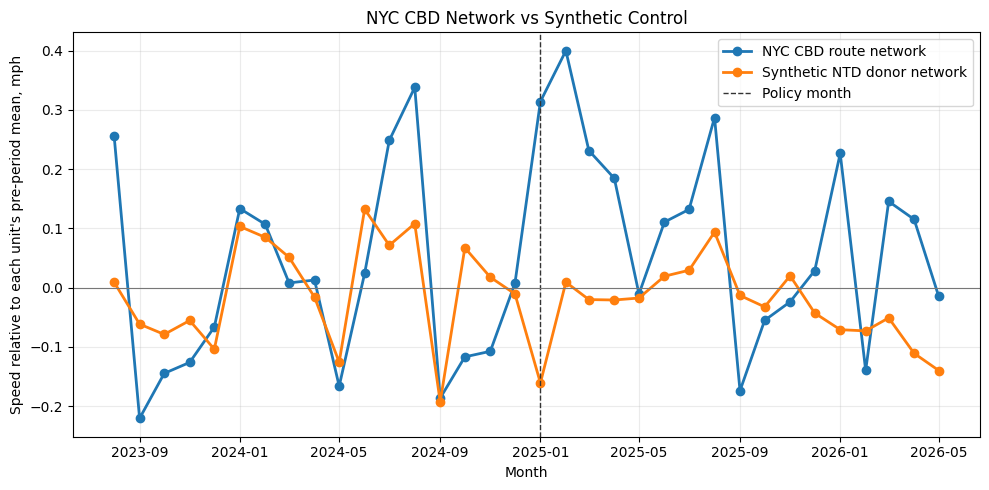

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result["month"], result["treated_centered_speed"], marker="o", linewidth=2, label="NYC CBD route network")
ax.plot(result["month"], result["synthetic_centered_speed"], marker="o", linewidth=2, label="Synthetic NTD donor network")
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("NYC CBD Network vs Synthetic Control")
ax.set_ylabel("Speed relative to each unit's pre-period mean, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "nyc_cbd_ntd_synthetic_control_fit.png", dpi=220, bbox_inches="tight")
plt.show()

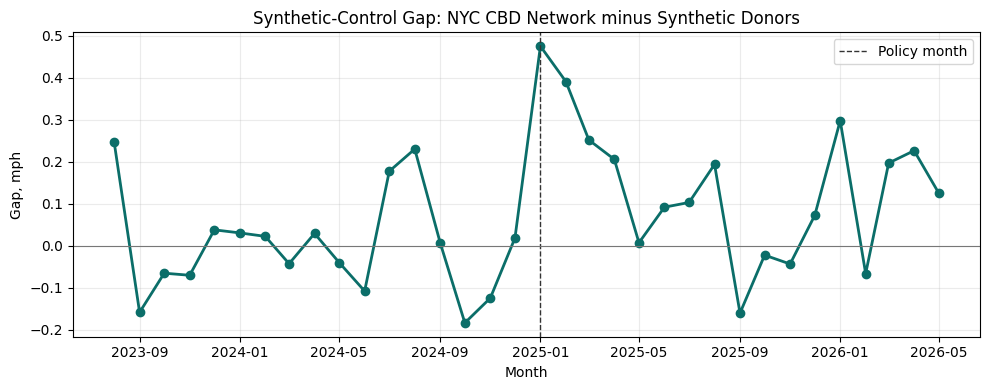

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result["month"], result["gap_mph"], marker="o", linewidth=2, color="#0b6e69")
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Synthetic-Control Gap: NYC CBD Network minus Synthetic Donors")
ax.set_ylabel("Gap, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "nyc_cbd_ntd_synthetic_control_gap.png", dpi=220, bbox_inches="tight")
plt.show()

## Step 7. Interpretation Guardrails

This design is most useful as a robustness exercise.

Strengths:

- donor pool is broad and built from a consistent national source;
- NYC-area agencies are excluded from the donor pool;
- weights are learned only from the pre-policy period;
- the treated unit matches the original GeoJSON treatment definition.

Limitations:

- NTD donor speeds are agency-level, not CBD-like route-subnetwork speeds;
- the treated NYC outcome is derived from route-level MTA bus speeds, while donor outcomes are VRM/VRH agency speeds;
- the pre-period has only 17 months, so overfitting remains a concern even with a limited donor pool;
- results should be read alongside the main NYC DiD and event-study diagnostics.

In [12]:
print("Saved outputs:")
for path in [
    PROCESSED / "ntd_monthly_bus_speeds.csv",
    TABLES / "ntd_synthetic_control_excluded_nyc_area_agencies.csv",
    TABLES / "ntd_synthetic_control_donor_pool.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_weights.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_monthly_results.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_summary.csv",
    FIGURES / "nyc_cbd_ntd_synthetic_control_fit.png",
    FIGURES / "nyc_cbd_ntd_synthetic_control_gap.png",
]:
    print(path.relative_to(ROOT))

Saved outputs:
data\processed\ntd_monthly_bus_speeds.csv
outputs\tables\ntd_synthetic_control_excluded_nyc_area_agencies.csv
outputs\tables\ntd_synthetic_control_donor_pool.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_weights.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_monthly_results.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_summary.csv
outputs\figures\nyc_cbd_ntd_synthetic_control_fit.png
outputs\figures\nyc_cbd_ntd_synthetic_control_gap.png


## Synthetic-Control Treatment-Definition Robustness

The primary synthetic control and every threshold variant use the main DiD common-support route universe. We repeat the exercise for the same CBD-share thresholds used in the NYC DiD robustness analysis while holding the NTD donor pool, fixed-route bus modes, analysis window, centering rule, and nonnegative sum-to-one constraint fixed.

The old official-source union is excluded because it is identical to the any-intersection route flag within the common-support sample. Repeating it would reproduce the same treated network mechanically.

Because NTD outcomes are monthly agency-level measures, this exercise remains a weekday monthly network comparison; it cannot reproduce the NYC route-level Peak/Off-Peak split.

In [13]:
SC_ROBUSTNESS = TABLES / "nyc_cbd_ntd_synthetic_control_robustness_summary.csv"
sc_robustness = pd.read_csv(SC_ROBUSTNESS)
sc_robustness[["treatment_column", "treatment_definition", "treated_routes", "donor_pool_size", "pre_rmspe", "post_mean_gap_mph", "post_mean_treated_change_mph", "post_mean_synthetic_change_mph"]]

,treatment_column,treatment_definition,treated_routes,donor_pool_size,pre_rmspe,post_mean_gap_mph,post_mean_treated_change_mph,post_mean_synthetic_change_mph
0,any_intersection,GeoJSON any policy-date route shape intersects...,81,35,0.120851,0.137563,0.103326,-0.034238
1,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,79,35,0.126073,0.147039,0.102619,-0.044420
2,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,75,35,0.121521,0.157128,0.110133,-0.046995
3,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,33,35,0.062046,0.133631,0.097341,-0.036290
4,max_share_ge_50pct,GeoJSON max shape share in CBD >= 50%,22,35,0.056162,0.123273,0.100437,-0.022836
5,max_share_ge_80pct,GeoJSON max shape share in CBD >= 80%,15,35,0.056286,0.157306,0.108026,-0.049280


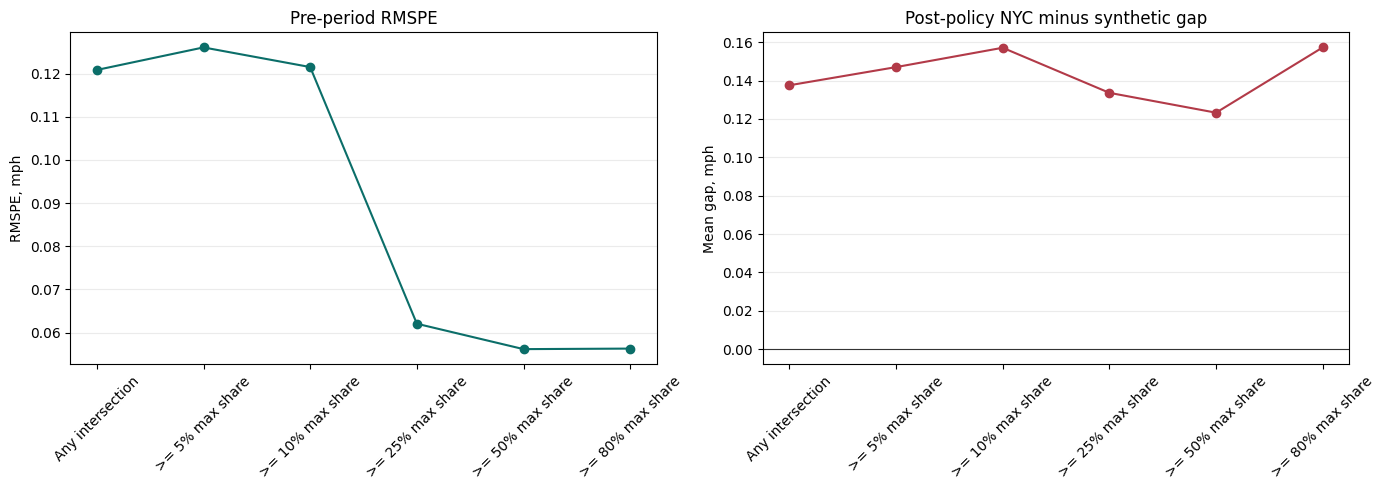

In [14]:
sc_plot = sc_robustness.copy()
sc_plot["label"] = sc_plot["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sc_plot["label"], sc_plot["pre_rmspe"], marker="o", color="#0b6e69")
axes[0].set_title("Pre-period RMSPE")
axes[0].set_ylabel("RMSPE, mph")
axes[1].plot(sc_plot["label"], sc_plot["post_mean_gap_mph"], marker="o", color="#b23a48")
axes[1].axhline(0, color="#333333", linewidth=0.8)
axes[1].set_title("Post-policy NYC minus synthetic gap")
axes[1].set_ylabel("Mean gap, mph")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

### Interpretation

The synthetic-control robustness result is most reassuring when the post-policy gap remains positive while pre-period RMSPE stays reasonably small across the original treatment and nearby thresholds. The threshold exercise is descriptive: changing the treated network changes the target unit, so the gaps should be compared for sign, magnitude, and pre-fit quality rather than treated as independent causal estimates. Very strict thresholds may leave a small treated network and can worsen comparability or make the result unstable. The synthetic-control evidence therefore complements, but does not replace, the route-level NYC DiD.


### Current run: synthetic-control conclusion

Using the 81 common-support any-intersection routes, the 35-donor post-policy NYC-minus-synthetic gap is **+0.138 mph**, with pre-period RMSPE **0.121 mph**. The 5% and 10% definitions yield gaps of **+0.147 mph** and **+0.157 mph**. All stricter thresholds remain positive, although they define smaller treated networks and are not independent confirmations.

For the primary definition, 30 donors yield RMSPE **0.147 mph** and a **+0.127 mph** gap; the 35- and 45-donor specifications both yield RMSPE **0.121 mph** and a **+0.138 mph** gap because candidates beyond the selected 35 receive no effective weight. The old official union is absent from the grid because it exactly duplicates the primary route set in the common-support sample.